<a href="https://www.kaggle.com/code/lalit7881/smartphone-battery-usage?scriptVersionId=301737083" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shayanzk/smartphone-battery-drain-and-usage-behavior/smartphone_battery_drain_dataset.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/shayanzk/smartphone-battery-drain-and-usage-behavior/smartphone_battery_drain_dataset.csv")

In [3]:
df.head()

,App_Running,Screen_On_Time_min,CPU_Usage_%,Battery_Temperature_C,Battery_Drop_Per_Hour,Network_Type,Brightness_Level_%,RAM_Usage_MB,Charging_State,Usage_Mode
0,Facebook,70.779244,55.550655,34.301005,6.020228,5G,57,2941.852469,Charging,Gaming
1,PUBG,90.044282,10.506832,35.607895,13.372379,WiFi,10,1930.581458,Not Charging,Social Media
2,Maps,75.197224,38.529769,43.312775,3.514550,5G,37,2169.828899,Charging,Social Media
3,WhatsApp,114.762495,26.898454,33.795197,6.728475,WiFi,33,2329.369145,Charging,Browsing
4,Facebook,52.214675,36.862349,41.089636,19.134837,5G,25,2175.002939,Charging,Video Streaming


In [4]:
df.tail()

,App_Running,Screen_On_Time_min,CPU_Usage_%,Battery_Temperature_C,Battery_Drop_Per_Hour,Network_Type,Brightness_Level_%,RAM_Usage_MB,Charging_State,Usage_Mode
2498,Instagram,56.488493,24.271686,40.431544,13.258253,WiFi,63,2187.176944,Not Charging,Gaming
2499,WhatsApp,80.865618,33.550557,24.552252,17.555962,5G,17,2653.751518,Charging,Gaming
2500,Chrome,64.043076,48.248489,26.177555,12.686444,WiFi,97,2734.017392,Not Charging,Browsing
2501,PUBG,85.989414,51.872556,29.039868,10.659386,4G,69,2451.633483,Charging,Browsing
2502,Spotify,108.595918,25.329861,40.802009,10.909154,WiFi,96,2417.584375,Charging,Browsing


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2503 entries, 0 to 2502
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   App_Running            2503 non-null   object 
 1   Screen_On_Time_min     2503 non-null   float64
 2   CPU_Usage_%            2498 non-null   float64
 3   Battery_Temperature_C  2498 non-null   float64
 4   Battery_Drop_Per_Hour  2503 non-null   float64
 5   Network_Type           2503 non-null   object 
 6   Brightness_Level_%     2503 non-null   int64  
 7   RAM_Usage_MB           2503 non-null   float64
 8   Charging_State         2503 non-null   object 
 9   Usage_Mode             2503 non-null   object 
dtypes: float64(5), int64(1), object(4)
memory usage: 195.7+ KB


In [6]:
df.describe()

,Screen_On_Time_min,CPU_Usage_%,Battery_Temperature_C,Battery_Drop_Per_Hour,Brightness_Level_%,RAM_Usage_MB
count,2503.000000,2498.000000,2498.000000,2503.000000,2503.000000,2503.000000
mean,79.800996,34.480392,34.989399,11.948375,51.902917,2197.331721
std,24.602660,15.003228,5.148660,4.843174,27.520267,589.813489
min,5.000000,1.000000,20.000000,1.000000,5.000000,500.000000
25%,62.817364,24.231843,31.522576,8.627100,27.000000,1797.226777
50%,79.865066,34.245258,34.983050,11.849516,52.000000,2196.626984
75%,96.825940,44.617992,38.508336,15.139305,76.000000,2596.435063
max,156.548674,83.602087,52.720325,27.516922,99.000000,4145.699243


In [7]:
df.isnull().sum()

App_Running              0
Screen_On_Time_min       0
CPU_Usage_%              5
Battery_Temperature_C    5
Battery_Drop_Per_Hour    0
Network_Type             0
Brightness_Level_%       0
RAM_Usage_MB             0
Charging_State           0
Usage_Mode               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(3)

In [9]:
df.dtypes

App_Running               object
Screen_On_Time_min       float64
CPU_Usage_%              float64
Battery_Temperature_C    float64
Battery_Drop_Per_Hour    float64
Network_Type              object
Brightness_Level_%         int64
RAM_Usage_MB             float64
Charging_State            object
Usage_Mode                object
dtype: object

In [10]:
df.shape

(2503, 10)

In [11]:
df.columns

Index(['App_Running', 'Screen_On_Time_min', 'CPU_Usage_%',
       'Battery_Temperature_C', 'Battery_Drop_Per_Hour', 'Network_Type',
       'Brightness_Level_%', 'RAM_Usage_MB', 'Charging_State', 'Usage_Mode'],
      dtype='object')

In [12]:
df.nunique()

App_Running                10
Screen_On_Time_min       2499
CPU_Usage_%              2459
Battery_Temperature_C    2491
Battery_Drop_Per_Hour    2471
Network_Type                3
Brightness_Level_%         95
RAM_Usage_MB             2496
Charging_State              2
Usage_Mode                  6
dtype: int64

## EDA

In [13]:
sns.set(style="whitegrid")

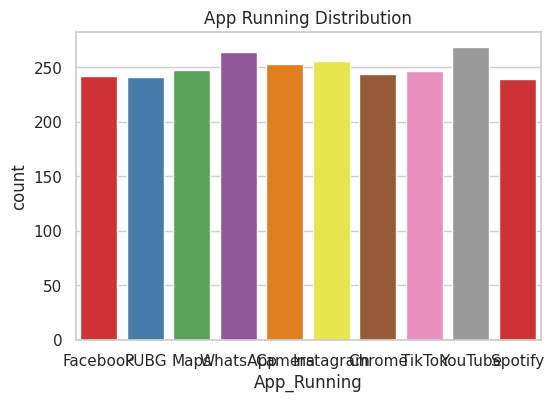

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='App_Running', data=df, palette='Set1')
plt.title("App Running Distribution")
plt.show()

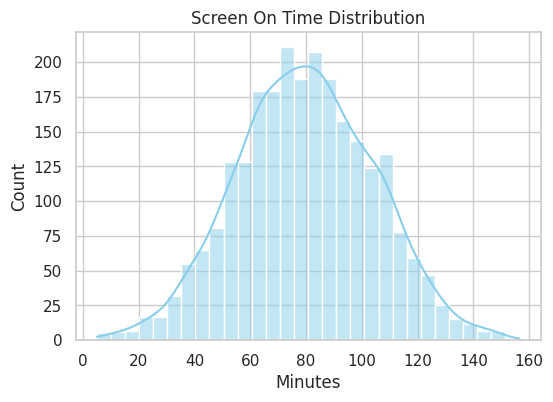

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['Screen_On_Time_min'], bins=30, color='skyblue', kde=True)
plt.title("Screen On Time Distribution")
plt.xlabel("Minutes")
plt.show()


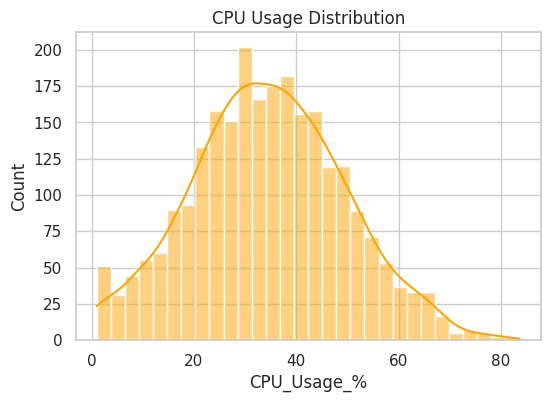

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df['CPU_Usage_%'], bins=30, color='orange', kde=True)
plt.title("CPU Usage Distribution")
plt.show()

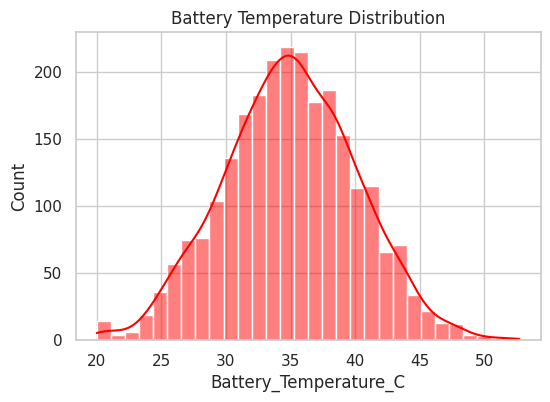

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df['Battery_Temperature_C'], bins=30, color='red', kde=True)
plt.title("Battery Temperature Distribution")
plt.show()

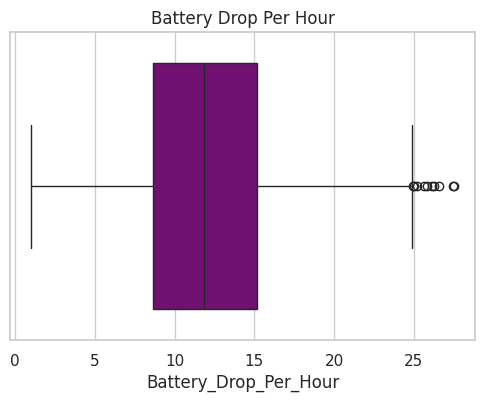

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Battery_Drop_Per_Hour'], color='purple')
plt.title("Battery Drop Per Hour")
plt.show()

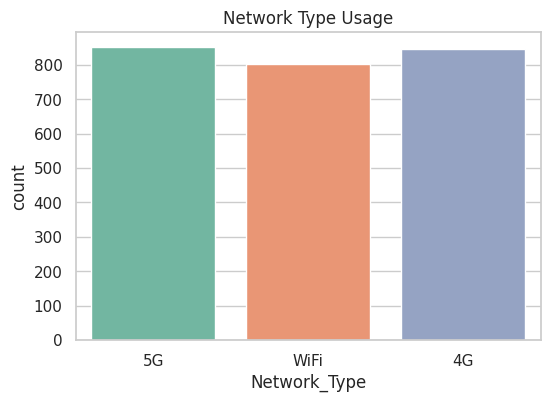

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Network_Type', data=df, palette='Set2')
plt.title("Network Type Usage")
plt.show()

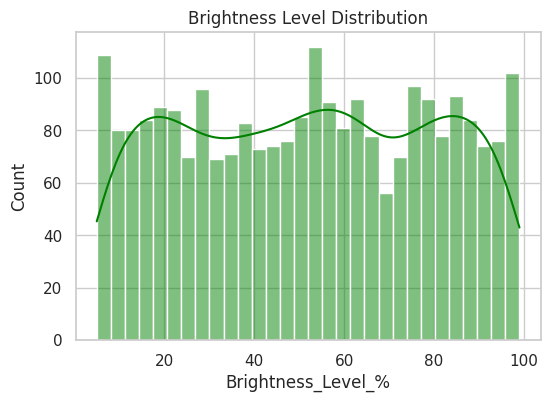

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(df['Brightness_Level_%'], bins=30, color='green', kde=True)
plt.title("Brightness Level Distribution")
plt.show()

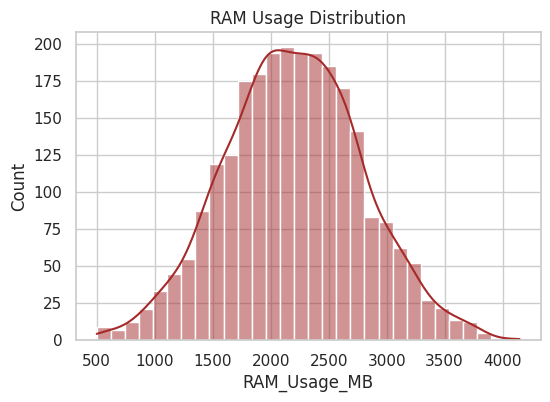

In [21]:
plt.figure(figsize=(6,4))
sns.histplot(df['RAM_Usage_MB'], bins=30, color='brown', kde=True)
plt.title("RAM Usage Distribution")
plt.show()

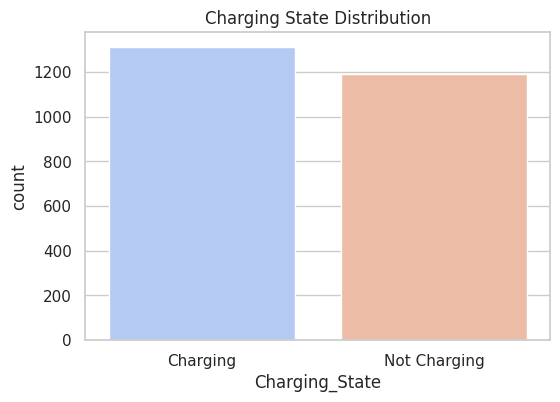

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='Charging_State', data=df, palette='coolwarm')
plt.title("Charging State Distribution")
plt.show()

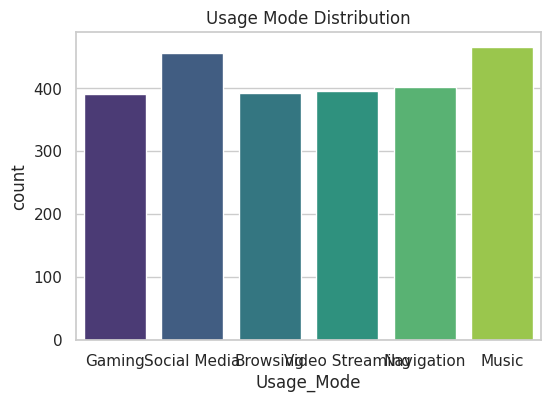

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='Usage_Mode', data=df, palette='viridis')
plt.title("Usage Mode Distribution")
plt.show()

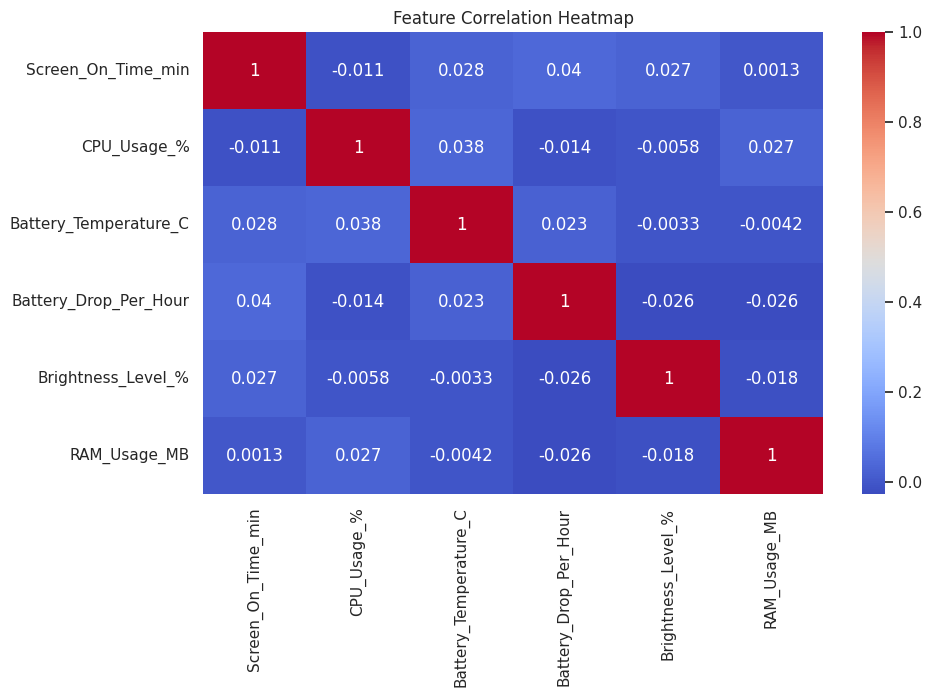

In [24]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

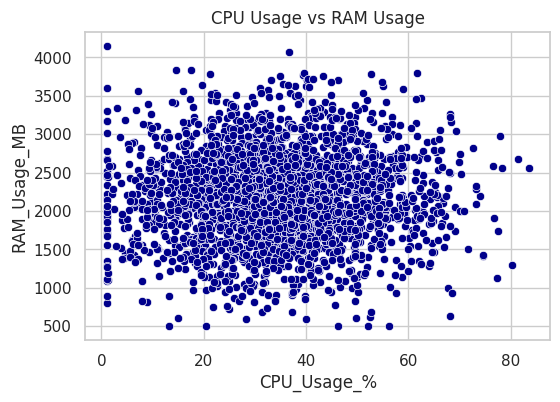

In [25]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='CPU_Usage_%', y='RAM_Usage_MB', data=df, color='darkblue')
plt.title("CPU Usage vs RAM Usage")
plt.show()

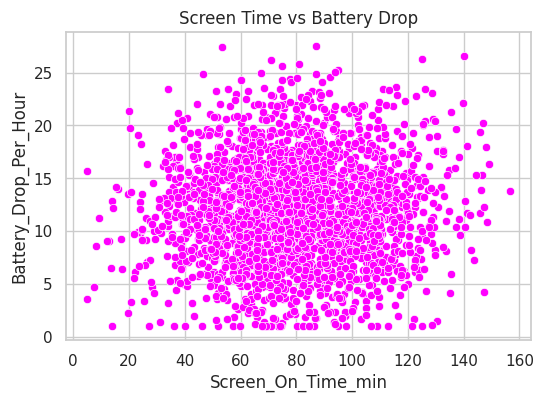

In [26]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Screen_On_Time_min', y='Battery_Drop_Per_Hour', data=df, color='magenta')
plt.title("Screen Time vs Battery Drop")
plt.show()

## Feature engineering

In [27]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [28]:
print(df.head())
print(df.info())

  App_Running  Screen_On_Time_min  CPU_Usage_%  Battery_Temperature_C  \
0    Facebook           70.779244    55.550655              34.301005   
1        PUBG           90.044282    10.506832              35.607895   
2        Maps           75.197224    38.529769              43.312775   
3    WhatsApp          114.762495    26.898454              33.795197   
4    Facebook           52.214675    36.862349              41.089636   

   Battery_Drop_Per_Hour Network_Type  Brightness_Level_%  RAM_Usage_MB  \
0               6.020228           5G                  57   2941.852469   
1              13.372379         WiFi                  10   1930.581458   
2               3.514550           5G                  37   2169.828899   
3               6.728475         WiFi                  33   2329.369145   
4              19.134837           5G                  25   2175.002939   

  Charging_State       Usage_Mode  
0       Charging           Gaming  
1   Not Charging     Social Media  
2 

In [29]:
le = LabelEncoder()

cat_cols = ['App_Running','Network_Type','Charging_State','Usage_Mode']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [30]:
X = df.drop("Usage_Mode", axis=1)
y = df["Usage_Mode"]

In [31]:
imputer = SimpleImputer(strategy="mean")

X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [33]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [34]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

    print("\n========================")
    print("MODEL:", name)
    print("========================")

    print("Accuracy:", round(acc*100,2), "%")
    print(classification_report(y_test, y_pred))


MODEL: Logistic Regression
Accuracy: 17.76 %
              precision    recall  f1-score   support

           0       0.19      0.06      0.09        81
           1       0.00      0.00      0.00        74
           2       0.18      0.51      0.27        88
           3       0.16      0.15      0.15        68
           4       0.22      0.20      0.21       105
           5       0.12      0.09      0.11        85

    accuracy                           0.18       501
   macro avg       0.14      0.17      0.14       501
weighted avg       0.15      0.18      0.14       501


MODEL: Decision Tree
Accuracy: 16.37 %
              precision    recall  f1-score   support

           0       0.14      0.11      0.12        81
           1       0.09      0.08      0.09        74
           2       0.20      0.23      0.21        88
           3       0.12      0.15      0.13        68
           4       0.23      0.22      0.22       105
           5       0.17      0.16      0.17   

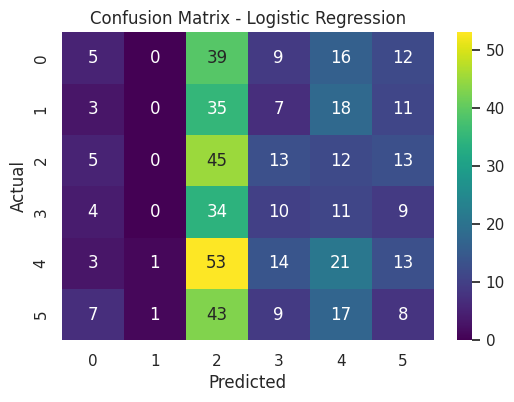

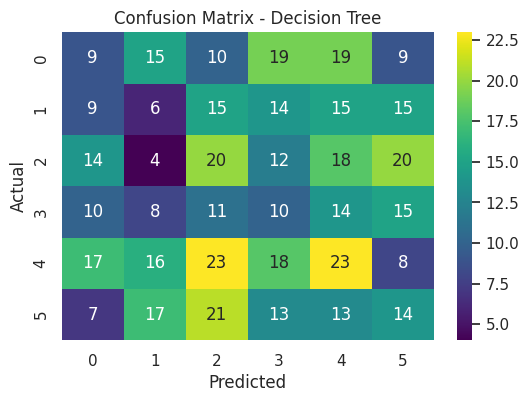

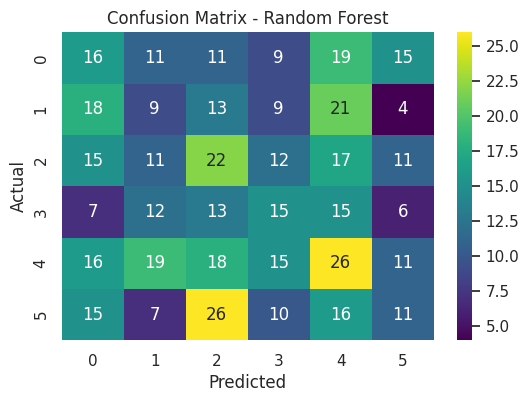

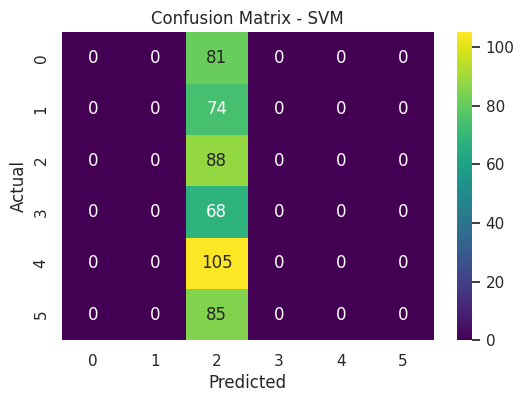

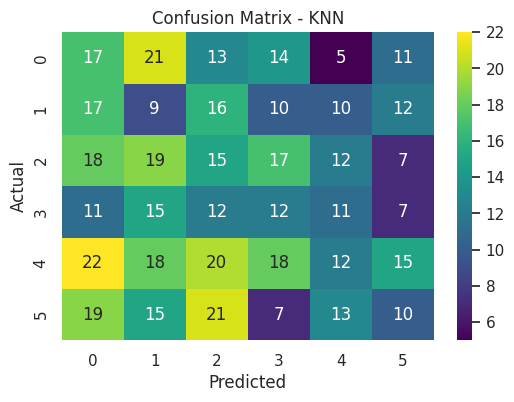

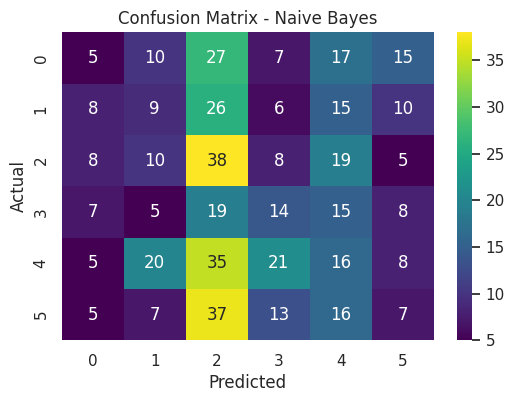

In [35]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))

    sns.heatmap(cm,
                annot=True,
                cmap="viridis",
                fmt='d')

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

## Thank you..pls upvote!!!!!!